# Analysis

In [220]:
from tools.utils import replace_minus_ones_with_prev
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import seaborn as sns


In [221]:
# labeldist = []
# for cl in ['opt-out','arbitration','class waiver','anti-scraping', 'modification']:

#     df = pd.read_csv(f'annotations/ollama_annotations/{cl}_labels_judged.csv', index_col=0)
#     labeldist.append(df['label_gpt-4o'].value_counts())

In [222]:
# pd.concat(labeldist, axis=1, keys=['opt-out','arbitration','class waiver','anti-scraping', 'modification']).fillna(0).sum(axis=0)

In [223]:
processed_data_dir = Path('processed_data/tous')
file_name = processed_data_dir / 'metadata_annotated_modernbert_2.tsv' # _annotated_distilbert
metadata = pd.read_csv(file_name,sep='\t')
metadata['year_int'] = metadata.year.apply(lambda x: int(str(x)[:4]))
metadata.fillna('', inplace=True)
metadata.shape

(124495, 13)

In [224]:
metadata.columns

Index(['platform', 'year', 'sentence', 'sentence_processed', 'tou_id', 'text',
       'prob_1_modification', 'modification', 'prob_1_arbitration',
       'arbitration', 'prob_1_anti-scraping', 'anti-scraping', 'year_int'],
      dtype='object')

In [312]:

threshold = 0.75
for clause_type in ['arbitration', 'modification','anti-scraping']: # 'opt-out','class waiver','anti-scraping',
    metadata[f'{clause_type}_recoded'] = 0
    metadata.loc[metadata[f'prob_1_{clause_type}'] >= threshold, f'{clause_type}_recoded'] = 1
    

In [313]:
# for clause_type in ['arbitration','modification','anti-scraping']: # 'class waiver', 'opt-out','arbitration','class waiver','anti-scraping', 'modification'
#     (metadata.groupby('year_int')[f'{clause_type}'].sum() / metadata.groupby('year_int').size()).plot(legend=True, label=clause_type, figsize=(6,6))

In [314]:
# for clause_type in ['arbitration','modification','anti-scraping']: # 'class waiver', 'opt-out','arbitration','class waiver','anti-scraping', 'modification'
#     (metadata.groupby('year_int')[f'{clause_type}'].sum()).plot(legend=True, label=clause_type, figsize=(6,6))

In [330]:
clause_type = 'anti-scraping' # 'arbitration' | 'anti-scraping' | 'class waiver' | 'modification'| 'opt-out' | 
display(metadata.groupby(f'{clause_type}_recoded').size())
display(metadata.groupby(f'{clause_type}').size())


anti-scraping_recoded
0    122628
1      1867
dtype: int64

anti-scraping
0    122971
1      1524
dtype: int64

In [331]:

data = metadata.groupby(['platform','year_int'])[f'{clause_type}_recoded'].sum().astype(bool).astype(int).unstack().fillna(-1)
#data = metadata.groupby(['platform','year_int'])[f'prob_1_{clause_type}'].max().unstack().fillna(-1)


In [332]:
#data = data.loc[(data > -1).sum(axis=1).sort_values(ascending=False).index]

In [333]:
data_count = metadata.groupby(['platform','year_int'])[f'{clause_type}_recoded'].sum().unstack().fillna(-1)
# sns.heatmap(data, cbar=True, cmap='YlGnBu', linewidths=.5, linecolor='gray')

<Axes: xlabel='year_int', ylabel='platform'>

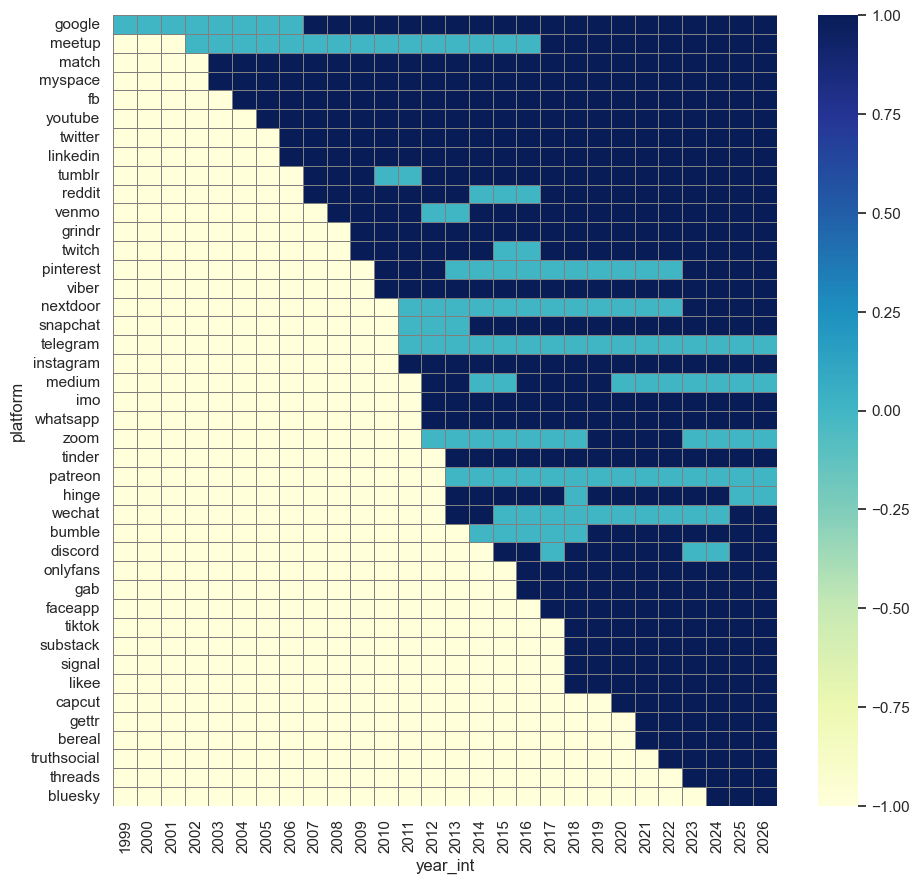

In [334]:
sns.set(rc={'figure.figsize':(10.7,10.27)})
data_replaced = replace_minus_ones_with_prev(data)
data_replaced = data_replaced.loc[(data_replaced > -1).sum(axis=1).sort_values(ascending=False).index]
data_replaced.to_csv(f'results/{clause_type}_heatmap_data.csv')
sns.heatmap(data_replaced,cbar=True, cmap='YlGnBu', linewidths=.5, linecolor='gray', vmin=-1, vmax=1)

<Axes: title={'center': 'Average anti-scraping prevalence per year'}, xlabel='year_int'>

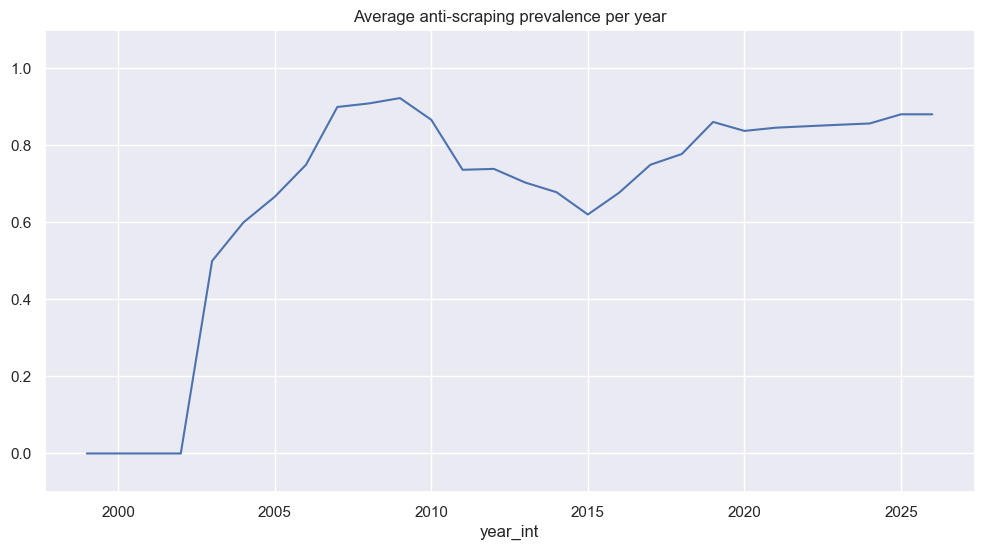

In [335]:
data_replaced.apply(lambda x: x.replace(-1, np.nan)).mean(axis=0, skipna=True).plot(figsize=(12,6), ylim=(-0.1,1.1), title=f'Average {clause_type} prevalence per year')

<Axes: xlabel='year_int', ylabel='platform'>

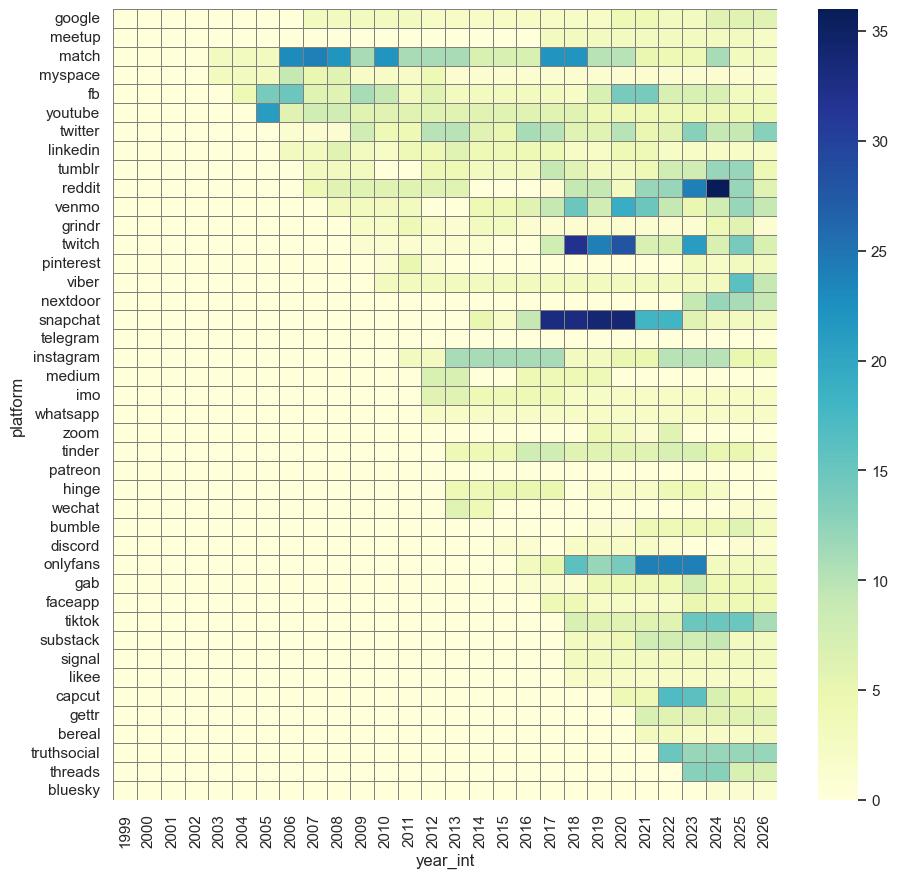

In [336]:
sns.set(rc={'figure.figsize':(10.7,10.27)})
data_replaced = replace_minus_ones_with_prev(data_count)
data_replaced = data_replaced.loc[(data_replaced > -1).sum(axis=1).sort_values(ascending=False).index]
data_replaced.to_csv(f'results/{clause_type}_heatmap_data.csv')
data_replaced[data_replaced < 0] = 0
sns.heatmap(data_replaced,cbar=True, cmap='YlGnBu', linewidths=.5, linecolor='gray', vmin=0, vmax=data_replaced.values.reshape(-1).max())

<Axes: title={'center': 'Average anti-scraping sent proportion per year'}, xlabel='year_int'>

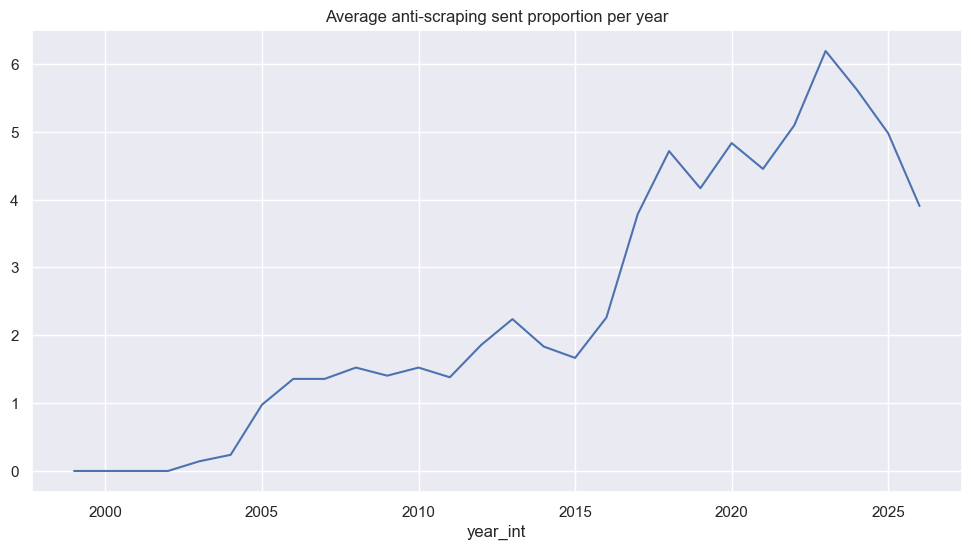

In [337]:
data_replaced.apply(lambda x: x.replace(-1, np.nan)).mean(axis=0, skipna=True).plot(figsize=(12,6),  title=f'Average {clause_type} sent proportion per year')

[Text(0, 0, '1999'),
 Text(1, 0, '2000'),
 Text(2, 0, '2001'),
 Text(3, 0, '2002'),
 Text(4, 0, '2003'),
 Text(5, 0, '2004'),
 Text(6, 0, '2005'),
 Text(7, 0, '2006'),
 Text(8, 0, '2007'),
 Text(9, 0, '2008'),
 Text(10, 0, '2009'),
 Text(11, 0, '2010'),
 Text(12, 0, '2011'),
 Text(13, 0, '2012'),
 Text(14, 0, '2013'),
 Text(15, 0, '2014'),
 Text(16, 0, '2015'),
 Text(17, 0, '2016'),
 Text(18, 0, '2017'),
 Text(19, 0, '2018'),
 Text(20, 0, '2019'),
 Text(21, 0, '2020'),
 Text(22, 0, '2021'),
 Text(23, 0, '2022'),
 Text(24, 0, '2023'),
 Text(25, 0, '2024'),
 Text(26, 0, '2025'),
 Text(27, 0, '2026')]

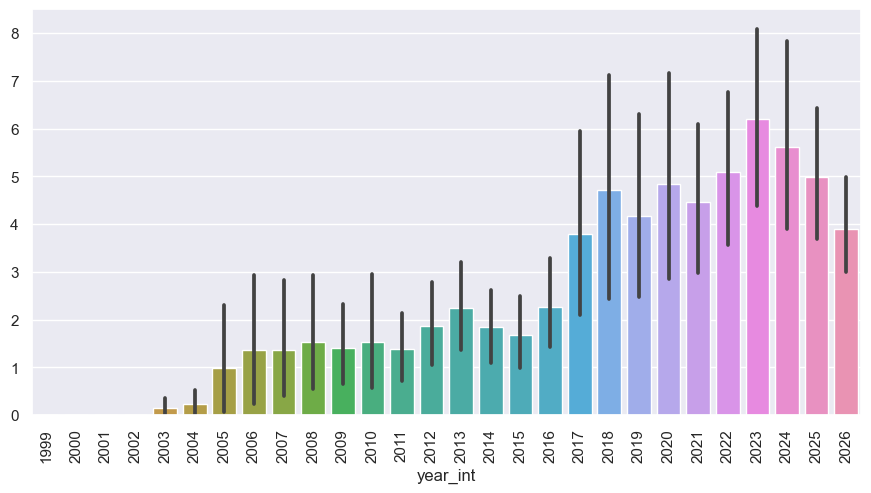

In [338]:
sns.set(rc={'figure.figsize':(10.7,5.27)})
g = sns.barplot(data=data_replaced)
g.set_xticklabels(g.get_xticklabels(),rotation=90)

<Axes: title={'center': 'Average anti-scraping sent proportion per year'}, xlabel='platform'>

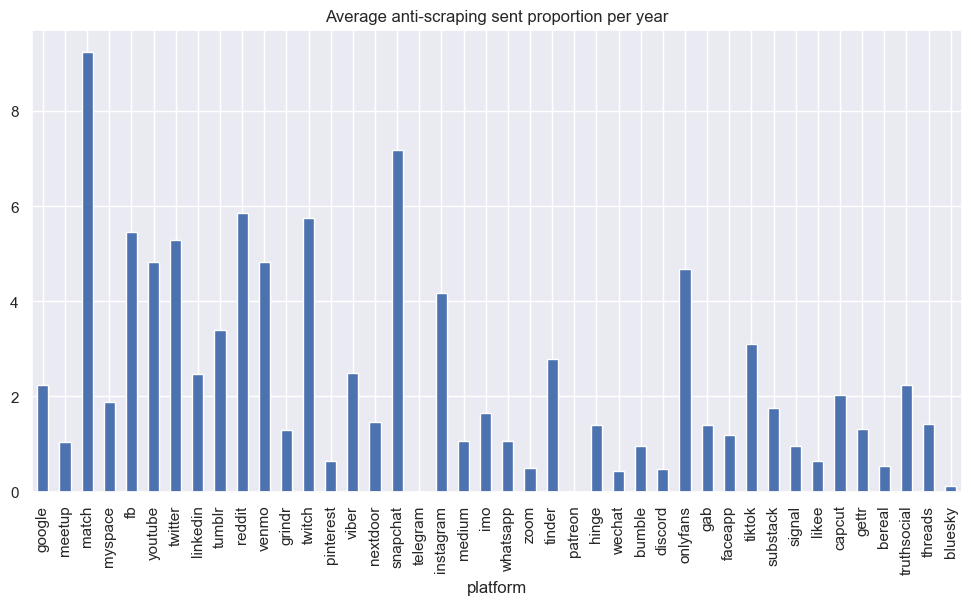

In [339]:
data_replaced.apply(lambda x: x.replace(-1, np.nan)).mean(axis=1, skipna=True).plot(kind='bar',figsize=(12,6),  title=f'Average {clause_type} sent proportion per year')

[Text(0, 0, 'google'),
 Text(1, 0, 'meetup'),
 Text(2, 0, 'match'),
 Text(3, 0, 'myspace'),
 Text(4, 0, 'fb'),
 Text(5, 0, 'youtube'),
 Text(6, 0, 'twitter'),
 Text(7, 0, 'linkedin'),
 Text(8, 0, 'tumblr'),
 Text(9, 0, 'reddit'),
 Text(10, 0, 'venmo'),
 Text(11, 0, 'grindr'),
 Text(12, 0, 'twitch'),
 Text(13, 0, 'pinterest'),
 Text(14, 0, 'viber'),
 Text(15, 0, 'nextdoor'),
 Text(16, 0, 'snapchat'),
 Text(17, 0, 'telegram'),
 Text(18, 0, 'instagram'),
 Text(19, 0, 'medium'),
 Text(20, 0, 'imo'),
 Text(21, 0, 'whatsapp'),
 Text(22, 0, 'zoom'),
 Text(23, 0, 'tinder'),
 Text(24, 0, 'patreon'),
 Text(25, 0, 'hinge'),
 Text(26, 0, 'wechat'),
 Text(27, 0, 'bumble'),
 Text(28, 0, 'discord'),
 Text(29, 0, 'onlyfans'),
 Text(30, 0, 'gab'),
 Text(31, 0, 'faceapp'),
 Text(32, 0, 'tiktok'),
 Text(33, 0, 'substack'),
 Text(34, 0, 'signal'),
 Text(35, 0, 'likee'),
 Text(36, 0, 'capcut'),
 Text(37, 0, 'gettr'),
 Text(38, 0, 'bereal'),
 Text(39, 0, 'truthsocial'),
 Text(40, 0, 'threads'),
 Text(41, 0,

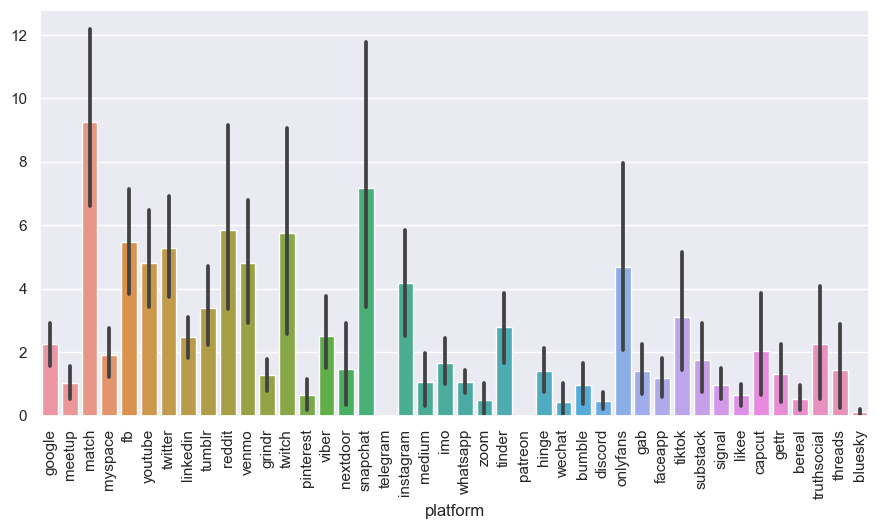

In [340]:
sns.set(rc={'figure.figsize':(10.7,5.27)})
g = sns.barplot(data=data_replaced.T)
g.set_xticklabels(g.get_xticklabels(),rotation=90)

In [341]:
# clause_data = metadata[metadata[f'{clause_type}_recoded'] == 1]
# index = clause_data.sort_values('year_int').index

In [ ]:
embeddings = np.loadtxt('processed_data/tous/embedding.tsv')

In [ ]:
# clause_embeddings = embeddings[index]
# clause_embeddings.shape[0], len(clause_data)

In [ ]:
# import scipy.spatial as sp
# from matplotlib import pyplot as plt
# sns.set()

# mult = 1 - sp.distance.cdist(clause_embeddings, clause_embeddings, 'cosine')
# sns.set(rc={'figure.figsize':(7.7,6.27)})
# sns.heatmap(mult)

In [ ]:
#
from collections import defaultdict
y2p = defaultdict(list)
for y,p in list(zip(*np.where(data.T >= 1))):
    y2p[y].append(p)


In [ ]:
data

In [ ]:
from itertools import combinations
import scipy.spatial as sp
results = []
for i in y2p.keys():
    combs = list(combinations(y2p[i], 2))
    # check similarity within the year
    for c in combs:    
        idx1 = metadata[(metadata.platform == data.index[c[0]]) & (metadata.year_int == data.columns[i]) & (metadata.modification_recoded == 1)].index
        idx2 = metadata[(metadata.platform == data.index[c[1]]) & (metadata.year_int == data.columns[i]) & (metadata.modification_recoded == 1)].index
        embeddings1= embeddings[list(idx1)]
        embeddings2= embeddings[list(idx2)]
        mult_comp = 1 - sp.distance.cdist(embeddings1, embeddings2, 'cosine')
        results.append([i, c[0], i,c[1], mult_comp.reshape(-1).max()])
    if i < len(y2p.keys()) - 1:
        for p in y2p[i]:
            idx1 = metadata[(metadata.platform == data.index[p]) & (metadata.year_int == data.columns[i]) & (metadata.modification_recoded == 1)].index
            for p2 in y2p[i+1]:
                idx2 = metadata[(metadata.platform == data.index[p2]) & (metadata.year_int == data.columns[i+1]) & (metadata.modification_recoded == 1)].index
                embeddings1= embeddings[list(idx1)]
                embeddings2= embeddings[list(idx2)]
                mult_comp = 1 - sp.distance.cdist(embeddings1, embeddings2, 'cosine')
                results.append([i, p, i+1, p2, mult_comp.reshape(-1).max()])
        
    

In [ ]:
results_filtered = [r for r in results if r[4] >= 0.9]

In [ ]:
results_filtered

In [ ]:
import plotly.graph_objects as go

In [ ]:
from itertools import product
nodes = list(product(range(data.shape[0]), range(data.shape[1])))
#nodes_label = list(range(len(nodes)))
nodes_label = [f'{data.index[n[0]]} - {data.columns[n[1]]}' for n in nodes]
x = [n[1]/data.shape[1] for n in nodes]
y = [n[0]/data.shape[0] for n in nodes]

In [ ]:
nodes = []
for r in results_filtered:
    nodes.append((r[1], r[0]))
    nodes.append((r[3], r[2]))
nodes_label = list(range(len(nodes)))
nodes_hover_label = [f'{data.index[n[0]]} - {data.columns[n[1]]}' for n in nodes]
x = [n[1]/data.shape[1] for n in nodes]
y = [n[0]/data.shape[0] for n in nodes]

In [ ]:
nodes2idx = {n: i for i, n in enumerate(nodes)}
nodes2idx

In [ ]:

source, target, value = [], [], []
for r in results_filtered:
    source.append(nodes2idx[(r[1], r[0])])
    target.append(nodes2idx[(r[3], r[2])])
    value.append(r[4])

In [ ]:
source, target

In [ ]:


fig = go.Figure(go.Sankey(
    arrangement = "snap",
    node = {
        "label": nodes_label,
        
        "x": x,
        "y": y,
        'customdata' : nodes_hover_label ,
      'hovertemplate':'%{customdata}',
        'pad':10},  # 10 Pixels
    link = {
        "source": source,
        "target": target,
        "value": value},
        )
        
    
)
fig.show(figsize=(20,20))

In [ ]:
import plotly.express as px

fig.write_html("figures/sankey_test.html")

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE


def plot_tsne(
    metadata: pd.DataFrame,
    embeddings: np.ndarray,
    color_by: str = "platform",       # "platform" | "year"
    perplexity: float = 30.0,
    n_iter: int = 1000,
    random_state: int = 42,
    title: str = "t-SNE projection of sentence embeddings",
) -> go.Figure:
    """
    Reduce embeddings to 2D with t-SNE and plot as an interactive scatter.

    Parameters
    ----------
    metadata     : DataFrame with 'year' and 'platform' columns.
    embeddings   : ndarray (N, D).
    color_by     : Column to use for point colour — 'platform' or 'year'.
    perplexity   : t-SNE perplexity. Rule of thumb: 5–50, scales with N.
    n_iter       : Number of optimisation iterations (≥250).
    random_state : Seed for reproducibility.
    title        : Figure title.
    """
    # 1. Fit t-SNE
    tsne = TSNE(
        n_components=3,
        perplexity=perplexity,
        n_iter=n_iter,
        random_state=random_state,
        init="pca",          # PCA init is more stable than random
        learning_rate="auto",
    )
    coords = tsne.fit_transform(embeddings)   # (N, 2)

    # 2. Build a plot-ready DataFrame
    plot_df = metadata[["year", "platform","sentence"]].copy().reset_index(drop=True)
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]
    plot_df["z"] = coords[:, 2]  # Add z coordinate for 3D plotting
    plot_df["year"] = plot_df["year"].astype(str)   # treat year as category

    # 3. Scatter plot
    fig = px.scatter_3d(
        plot_df,
        x="x",
        y="y",
        z="z",  # Add a third dimension
        color=color_by,
        hover_data={"x": False, "y": False, "z": False, "platform": True, "year": True, "sentence": True},
        title=title,
        labels={"x": "t-SNE 1", "y": "t-SNE 2", "z": "t-SNE 3"},
        #color_discrete_sequence=PLATFORM_COLORS,
        opacity=0.75,
    )

    fig.update_traces(marker=dict(size=6, line=dict(width=0.3, color="white")))
    fig.update_layout(
        plot_bgcolor="white",
        paper_bgcolor="white",
        legend_title=color_by.capitalize(),
        margin=dict(l=40, r=40, t=60, b=40),
        width=750,
        height=550,
    )
    fig.update_xaxes(showgrid=False, zeroline=False, showticklabels=False)
    fig.update_yaxes(showgrid=False, zeroline=False, showticklabels=False)

    return fig

In [ ]:
type(embeddings)

In [ ]:
metadata_selected = metadata[metadata.modification_recoded == 1]
metadata_selected = metadata_selected.dropna(subset=['platform', 'sentence'])
embeddings_selected = embeddings[metadata_selected.index]

In [ ]:
# Colour points by platform
fig = plot_tsne(metadata_selected, embeddings_selected, color_by="platform")
fig.show()



In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from tools.modification_sankey import build_sankey

In [ ]:
embeddings = np.loadtxt('processed_data/tous/embedding.tsv')

In [ ]:
metadata.shape, embeddings.shape

In [ ]:
build_sankey(metadata, embeddings)

## Fin